# Profit Emergence & Product Economics

**Core question:** a product may have a 10% lifetime PV margin — but *when* does the insurer
actually earn that profit?

Notebook 03 derived the indicated premium and confirmed the lifetime margin lands exactly on
target. That is a single number covering 20 years. This notebook is about **time**: the shape of
the profit stream, when the insurer is exposed, and which durations do the economic damage.

**Contents**

1. [The profit signature](#Part-1) — per-year profit, PV profit, cumulative PV profit.
2. [Break-even year & payback](#Part-2) — $T^*$, and what it does (and does not) mean here.
3. [Profit signature comparison](#Part-3) — same 10% margin, radically different timing.
4. [Lapse risk & stranded acquisition cost](#Part-4) — lapse drag, duration by duration.
5. [Mortality shock by duration](#Part-5) — rate shock vs. per-event severity; the danger map.
6. [Profit distribution across the portfolio](#Part-6) — all 10,000 policies, profit density.
7. ["Bad business" identification](#Part-7) — loss-making policies at book premium.

> **Assumptions basis.** Unlike notebook 03 (which fixed a round 4% purely so hand-arithmetic was
> easy to follow), this notebook runs on the project's **real, unmodified base assumptions** —
> including the 5.16% 20-Year Treasury discount rate and the 10% target PV margin from
> `config/assumptions.yaml`. Every stress in Parts 4–5 is applied through
> `life_pricing.scenario.apply_scenario`, which deep-copies the assumption dict, so nothing here
> is ever written back to the configuration.

> **One modelling decision that drives everything in Parts 4–5.** When we stress lapse or
> mortality, the premium is **held fixed at the base indicated premium**. That is the
> economically meaningful experiment: an insurer sets the rate at issue and *cannot* reprice a
> 20-year level term policy afterwards. Re-solving the premium under each stress would answer a
> different (and much less interesting) question — "what would we have charged if we had known?"
> — and would mechanically force every scenario back to a 10% margin, hiding exactly the risk we
> are trying to measure.

## Setup

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from life_pricing.config import load_assumptions
from life_pricing.mortality import mortality_curve_for_policy, write_processed_tables
from life_pricing.projection import project_policy
from life_pricing.premium import solve_annual_premium
from life_pricing.cashflow import build_policy_cash_flows, summarize_policy
from life_pricing.scenario import apply_scenario
from life_pricing.portfolio import generate_synthetic_portfolio
from life_pricing.portfolio_pricing import evaluate_portfolio_pricing

# Validated categorical palette, fixed slot order (never cycled).
BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
INK, SECONDARY_INK, MUTED, GRID, BASELINE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
GOOD, CRITICAL = "#0ca30c", "#d03b3b"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": SECONDARY_INK,
    "axes.titlecolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": INK,
    "grid.color": GRID,
    "font.size": 10,
})

DOLLARS = FuncFormatter(lambda x, _: f"${x:,.0f}")


def style(ax, drop_left=False):
    ax.grid(axis="y", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    for spine in (["top", "right", "left"] if drop_left else ["top", "right"]):
        ax.spines[spine].set_visible(False)
    return ax


write_processed_tables()  # idempotent; regenerates data/processed/ from data/raw/
ASSUMPTIONS = load_assumptions(ROOT / "config" / "assumptions.yaml")

print(f"Interest rate       i = {ASSUMPTIONS.discount_rate:.4%}")
print(f"Target PV margin    m = {ASSUMPTIONS.target_profit_margin:.2%}")
print(f"Term                  = {ASSUMPTIONS.term_years} years")

Interest rate       i = 5.1600%
Target PV margin    m = 10.00%
Term                  = 20 years


One helper does the whole Loop 2→7 pipeline for a policy, optionally at a **fixed** premium
(rather than re-solving) — which is what every stress test below needs.

In [2]:
def price_policy(assumptions, issue_age, sex, smoker_status, underwriting_class, face_amount,
                 mortality_rates_qx=None, annual_premium=None):
    """Run mortality -> projection -> (premium solve) -> cash flows for one policy.

    `mortality_rates_qx` overrides the table-derived curve (used for mortality shocks).
    `annual_premium` overrides the solved premium (used to hold the rate fixed under stress).
    Returns (premium, cash_flows, summary).
    """

    qx = mortality_rates_qx
    if qx is None:
        qx = mortality_curve_for_policy(
            assumptions, issue_age=issue_age, sex=sex, smoker_status=smoker_status,
            underwriting_class=underwriting_class, face_amount=face_amount,
        )
    projection = project_policy(
        assumptions, issue_age=issue_age, mortality_rates_qx=qx, face_amount=face_amount
    )
    premium = solve_annual_premium(assumptions, projection) if annual_premium is None else annual_premium
    cash_flows = build_policy_cash_flows(assumptions, projection, premium)
    return premium, cash_flows, summarize_policy(cash_flows)


def signature_frame(cash_flows):
    """Per-year profit signature table, including cumulative PV profit."""

    rows = []
    for r in cash_flows:
        rows.append({
            "Year": r.policy_year,
            "Premium": r.expected_premium,
            "Claims": r.expected_death_benefit,
            "Expenses": r.acquisition_expense + r.maintenance_expense + r.premium_related_expense,
            "Profit": r.net_cash_flow,
            "PV Profit": r.present_value_net_cash_flow,
        })
    frame = pd.DataFrame(rows)
    frame["Cum. PV Profit"] = frame["PV Profit"].cumsum()
    return frame


def break_even_year(frame):
    """T* = min{t : CumPVProfit_t >= 0}; None if never recovered."""

    recovered = frame.loc[frame["Cum. PV Profit"] >= 0, "Year"]
    return int(recovered.iloc[0]) if len(recovered) else None


print("helpers defined")

helpers defined


<a id="Part-1"></a>
## Part 1 — Build the profit signature

For every policy year:

$$ Profit_t = Premium_t - Claims_t - Expenses_t $$

$$ PVProfit_t = Profit_t \, v^t \qquad\text{and}\qquad CumPVProfit_t = \sum_{j=1}^{t} PVProfit_j $$

**A precision note on $v^t$.** Writing $PVProfit_t = Profit_t \, v^t$ assumes every component of
year $t$'s cash flow occurs at the same instant. This project's V1.1 timing correction
(`ACTUARIAL_ASSUMPTIONS.md`) says otherwise: the premium arrives at the *start* of the year
($v^{t-1}$), the claim at the *end* ($v^t$), maintenance expense mid-year ($v^{t-0.5}$). So the
`PV Profit` column below is the engine's `present_value_net_cash_flow` — each piece discounted at
its own timing and then netted — not the nominal profit times a single factor. The `Profit`
column remains the *nominal* (undiscounted) same-year accounting figure.

In [3]:
POLICY = dict(
    issue_age=40, sex="male", smoker_status="nonsmoker",
    underwriting_class="Standard", face_amount=500_000,
)

base_premium, base_cash_flows, base_summary = price_policy(ASSUMPTIONS, **POLICY)
signature = signature_frame(base_cash_flows)

print(f"Indicated annual premium: ${base_premium:,.2f}")
print(f"Lifetime PV profit:       ${base_summary.pv_profit:,.2f}")
print(f"Lifetime PV margin:       {base_summary.pv_profit_margin:.4%}  (target {ASSUMPTIONS.target_profit_margin:.2%})")

display_signature = signature.copy()
for col in ["Premium", "Claims", "Expenses", "Profit", "PV Profit", "Cum. PV Profit"]:
    display_signature[col] = display_signature[col].map(lambda x: f"{x:,.2f}")
display_signature.set_index("Year")

Indicated annual premium: $665.19
Lifetime PV profit:       $629.92
Lifetime PV margin:       10.0000%  (target 10.00%)


,Premium,Claims,Expenses,Profit,PV Profit,Cum. PV Profit
Year,,,,,,
1,665.19,85.00,376.30,203.89,209.55,209.55
2,625.17,140.98,87.65,396.55,385.00,594.55
3,590.61,190.89,82.80,316.91,296.24,890.79
4,562.61,215.68,78.88,268.06,240.69,"1,131.48"
5,538.14,238.66,75.45,224.04,193.76,"1,325.24"
6,516.31,263.90,72.39,180.02,150.95,"1,476.19"
7,496.87,283.85,69.66,143.36,117.13,"1,593.32"
8,479.61,306.43,67.24,105.94,85.82,"1,679.14"
9,463.87,338.21,65.03,60.62,52.33,"1,731.46"


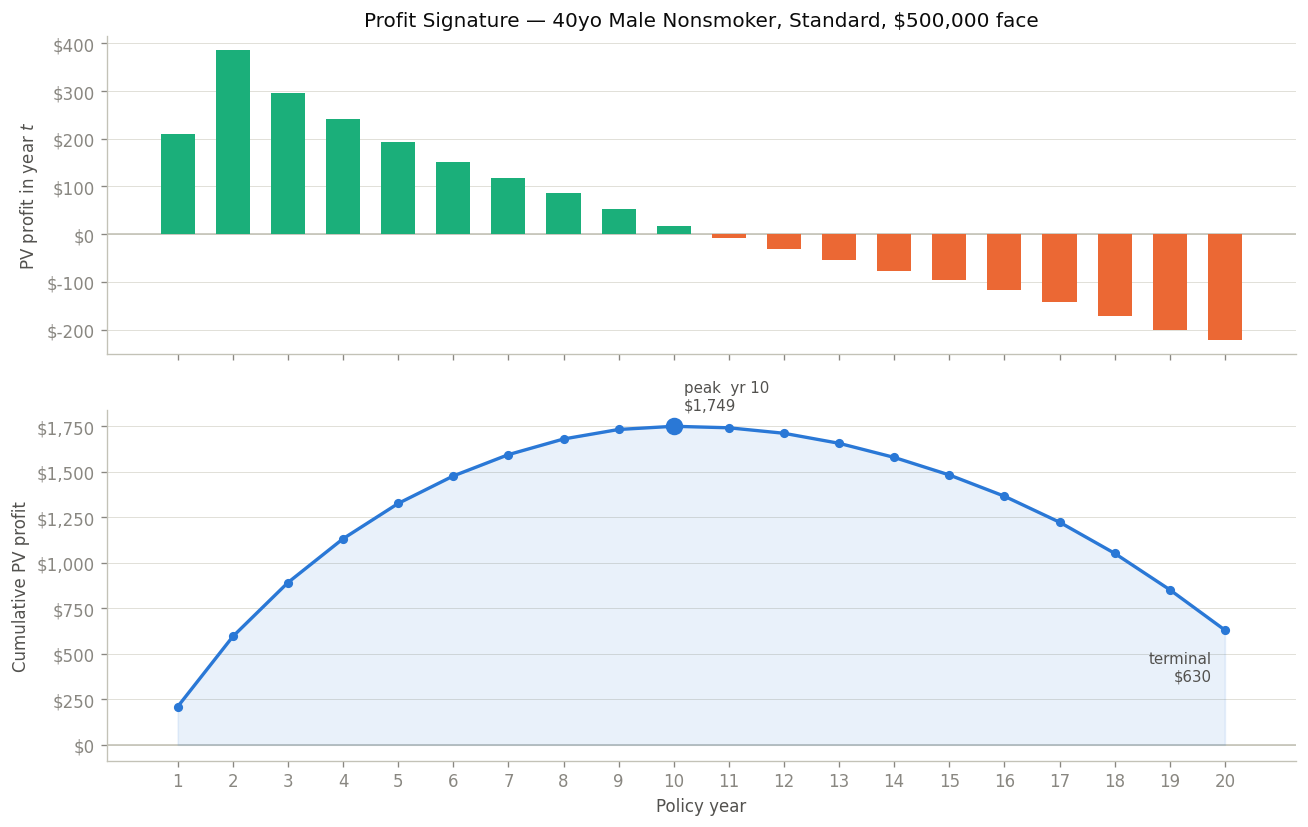

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, height_ratios=[1, 1.1])

colors = [AQUA if v >= 0 else ORANGE for v in signature["PV Profit"]]
ax1.bar(signature["Year"], signature["PV Profit"], color=colors, width=0.62, zorder=2)
ax1.axhline(0, color=BASELINE, linewidth=1.0, zorder=1)
ax1.set_ylabel("PV profit in year $t$")
ax1.set_title(
    f"Profit Signature — {POLICY['issue_age']}yo {POLICY['sex'].title()} "
    f"{POLICY['smoker_status'].title()}, {POLICY['underwriting_class']}, ${POLICY['face_amount']:,} face"
)
ax1.yaxis.set_major_formatter(DOLLARS)
style(ax1)

ax2.plot(signature["Year"], signature["Cum. PV Profit"], color=BLUE, marker="o", markersize=4.5, linewidth=2, zorder=3)
ax2.axhline(0, color=BASELINE, linewidth=1.0, zorder=1)
ax2.fill_between(signature["Year"], 0, signature["Cum. PV Profit"], color=BLUE, alpha=0.10, zorder=2)

peak_idx = signature["Cum. PV Profit"].idxmax()
peak_year, peak_value = int(signature.loc[peak_idx, "Year"]), signature.loc[peak_idx, "Cum. PV Profit"]
terminal = signature["Cum. PV Profit"].iloc[-1]
ax2.scatter([peak_year], [peak_value], s=90, color=BLUE, zorder=4)
ax2.annotate(f"peak  yr {peak_year}\n${peak_value:,.0f}", (peak_year, peak_value),
             textcoords="offset points", xytext=(6, 10), fontsize=9, color=SECONDARY_INK)
ax2.annotate(f"terminal\n${terminal:,.0f}", (20, terminal),
             textcoords="offset points", xytext=(-8, -30), fontsize=9, color=SECONDARY_INK, ha="right")

ax2.set_xlabel("Policy year")
ax2.set_ylabel("Cumulative PV profit")
ax2.set_xticks(range(1, ASSUMPTIONS.term_years + 1))
ax2.yaxis.set_major_formatter(DOLLARS)
style(ax2)

plt.tight_layout()
plt.show()

The shape is the headline, and it is not the one most people expect. Profit for this product is
**front-loaded**: every year from 1 to 10 contributes positive PV profit, and every year from 11
to 20 destroys some of it. Cumulative PV profit climbs to a peak around year 10 and then gives a
large fraction of it back.

The mechanism is the defining feature of *level-premium* term. The premium is flat for 20 years,
but $q_t$ roughly doubles between issue and the end of the term (see notebook 03's mortality
vector). Early on the level premium substantially over-covers the year's mortality cost; late on
it under-covers it. Because we hold no reserve in this model (see Part 2), that early surplus is
simply recognised as profit rather than being set aside to fund the shortfall it is
mathematically guaranteed to meet later.

<a id="Part-2"></a>
## Part 2 — Find the break-even year

$$ T^* = \min\{t : CumPVProfit_t \ge 0\} $$

In [5]:
initial_strain = signature.loc[0, "PV Profit"]
T_star = break_even_year(signature)
lifetime_pv_profit = signature["Cum. PV Profit"].iloc[-1]

print(f"Initial strain:       ${initial_strain:,.2f}")
print(f"Break-even year:      {T_star}")
print(f"20-year PV profit:    ${lifetime_pv_profit:,.2f}")

Initial strain:       $209.55
Break-even year:      1
20-year PV profit:    $629.92


### The honest finding: this product has no acquisition strain

The framing behind "break-even year" is that an insurer pays acquisition costs up front, runs a
**negative** first year, and then waits several years to recover. That is the classic picture —
but it is not what this model produces, and reporting $T^*=6$ when the engine says $T^*=1$ would
be fabricating a result. Year 1 is *profitable*, so $T^*$ is trivially 1 and the payback concept
has nothing to bite on. Two concrete reasons, both verifiable:

In [6]:
year_one = base_cash_flows[0]
print("Year 1 cash flow decomposition (nominal):")
print(f"  Premium collected                       + ${year_one.expected_premium:>10,.2f}")
print(f"  Expected death benefit                  - ${year_one.expected_death_benefit:>10,.2f}")
print(f"  Acquisition expense (fixed, at issue)   - ${year_one.acquisition_expense:>10,.2f}")
print(f"  Acquisition expense (% of premium)      - ${year_one.premium_related_expense:>10,.2f}")
print(f"  Maintenance expense                     - ${year_one.maintenance_expense:>10,.2f}")
print(f"  {'-' * 52}")
print(f"  Year 1 nominal profit                   = ${year_one.net_cash_flow:>10,.2f}")
print()
acq_pct = ASSUMPTIONS.acquisition_pct_first_year_premium
print(f"First-year acquisition load = {acq_pct:.0%} of premium (config/assumptions.yaml).")
print("A real term-life first-year commission is commonly 80-120% of premium.")

Year 1 cash flow decomposition (nominal):
  Premium collected                       + $    665.19
  Expected death benefit                  - $     85.00
  Acquisition expense (fixed, at issue)   - $    150.00
  Acquisition expense (% of premium)      - $    166.30
  Maintenance expense                     - $     60.00
  ----------------------------------------------------
  Year 1 nominal profit                   = $    203.89

First-year acquisition load = 25% of premium (config/assumptions.yaml).
A real term-life first-year commission is commonly 80-120% of premium.


**Reason 1 — the configured first-year acquisition load is modest.** At 25% of premium plus a
$150 fixed cost, first-year outgo simply does not exceed the first-year premium. Real term
products typically pay a first-year commission near 100% of premium, which is what turns year 1
negative.

**Reason 2 — and this one matters more — this model holds no reserves.** Statutory reserves and
VM-20 are explicitly out of scope (`PROJECT_SPEC.md` section 9, `MODEL_LIMITATIONS.md`). In a real
profit-emergence study the year-1 loss is dominated not by commission but by the requirement to
*establish* a reserve, and profit emerges as that reserve unwinds. Because this engine recognises
the whole level-premium surplus as it is collected, it front-loads profit that a reserved model
would defer — which is exactly the pattern Part 1's chart shows.

So for *this* product, the informative metrics are not "when do we break even" but **when does
cumulative profit peak, and how much is given back afterwards**:

In [7]:
give_back = peak_value - terminal
print(f"Peak cumulative PV profit:   ${peak_value:,.2f}  (year {peak_year})")
print(f"Terminal PV profit:          ${terminal:,.2f}")
print(f"Give-back after the peak:    ${give_back:,.2f}  ({give_back / peak_value:.1%} of peak)")
print()
print(f"Years contributing positive PV profit: {(signature['PV Profit'] > 0).sum()} of {len(signature)}")

Peak cumulative PV profit:   $1,749.02  (year 10)
Terminal PV profit:          $629.92
Give-back after the peak:    $1,119.09  (64.0% of peak)

Years contributing positive PV profit: 10 of 20


### Payback comparison across risk profiles

Even though $T^*$ is degenerate under the configured expense basis, the *comparison* the brief
asks for is still worth making — so we run it two ways. Alongside the real basis we run an
**illustrative** basis with a 100%-of-premium first-year commission, which is representative of
real term-life distribution economics and does create genuine year-1 strain. That variant is a
labelled teaching device applied through `apply_scenario`; it is never written back to
`config/assumptions.yaml`, and every other number in this notebook uses the real basis.

In [8]:
ILLUSTRATIVE_HIGH_COMMISSION = apply_scenario(
    ASSUMPTIONS, lambda raw: raw["expenses"].update(acquisition_pct_first_year_premium=1.00)
)
assert ASSUMPTIONS.acquisition_pct_first_year_premium == 0.25  # base untouched

PROFILES = [
    dict(issue_age=age, sex="male", smoker_status=smoker,
         underwriting_class=uw_class, face_amount=500_000)
    for age in (30, 40, 50, 60)
    for uw_class in ("Preferred Plus", "Standard")
    for smoker in ("nonsmoker", "smoker")
]

rows = []
for profile in PROFILES:
    premium, cash_flows, summary = price_policy(ASSUMPTIONS, **profile)
    frame = signature_frame(cash_flows)
    hc_premium, hc_cash_flows, _ = price_policy(ILLUSTRATIVE_HIGH_COMMISSION, **profile)
    hc_frame = signature_frame(hc_cash_flows)
    rows.append({
        "Age": profile["issue_age"],
        "UW class": profile["underwriting_class"],
        "Smoker": profile["smoker_status"],
        "Premium": premium,
        "Yr-1 PV profit": frame.loc[0, "PV Profit"],
        "T* (base)": break_even_year(frame),
        "Peak yr": int(frame["Cum. PV Profit"].idxmax()) + 1,
        "PV profit": frame["Cum. PV Profit"].iloc[-1],
        "Yr-1 PV (100% comm.)": hc_frame.loc[0, "PV Profit"],
        "T* (100% comm.)": break_even_year(hc_frame),
    })

payback = pd.DataFrame(rows)
payback_display = payback.copy()
for col in ["Premium", "Yr-1 PV profit", "PV profit", "Yr-1 PV (100% comm.)"]:
    payback_display[col] = payback_display[col].map(lambda x: f"${x:,.0f}")
payback_display

,Age,UW class,Smoker,Premium,Yr-1 PV profit,T* (base),Peak yr,PV profit,Yr-1 PV (100% comm.),T* (100% comm.)
0,30,Preferred Plus,nonsmoker,$260,$-60,2,11,$247,$-255,3
1,30,Preferred Plus,smoker,$498,$75,1,11,$473,$-299,2
2,30,Standard,nonsmoker,$367,$-9,2,10,$349,$-285,3
3,30,Standard,smoker,$754,$209,1,11,$713,$-356,2
4,40,Preferred Plus,nonsmoker,$444,$75,1,10,$421,$-258,2
5,40,Preferred Plus,smoker,$987,$388,1,10,$932,$-352,2
6,40,Standard,nonsmoker,$665,$210,1,10,$630,$-289,2
7,40,Standard,smoker,"$1,542",$715,1,10,"$1,449",$-441,2
8,50,Preferred Plus,nonsmoker,$977,$372,1,10,$923,$-360,2
9,50,Preferred Plus,smoker,"$2,658","$1,461",1,9,"$2,474",$-533,2


Under the real basis, year 1 is positive for every profile except the youngest, cheapest ones
(age 30 nonsmokers), where the flat $150 acquisition cost is large relative to a small premium —
those are the only cells with a genuine, if brief, payback period. Under the illustrative 100%
commission every profile shows year-1 strain, and payback still completes by year 2–3, because
year 2 profit is large for exactly the reason Part 1 explained.

<a id="Part-3"></a>
## Part 3 — Profit signature comparison

Three policies, all priced to the **same 10% lifetime PV margin**. Same lifetime return does not
mean the same financial profile.

In [9]:
COMPARISON = [
    ("Age 30 · nonsmoker · Preferred Plus",
     dict(issue_age=30, sex="male", smoker_status="nonsmoker", underwriting_class="Preferred Plus", face_amount=500_000),
     BLUE),
    ("Age 40 · nonsmoker · Standard",
     dict(issue_age=40, sex="male", smoker_status="nonsmoker", underwriting_class="Standard", face_amount=500_000),
     ORANGE),
    ("Age 50 · smoker · Standard",
     dict(issue_age=50, sex="male", smoker_status="smoker", underwriting_class="Standard", face_amount=500_000),
     AQUA),
]

comparison_frames = {}
summary_rows = []
for label, profile, _ in COMPARISON:
    premium, cash_flows, summary = price_policy(ASSUMPTIONS, **profile)
    frame = signature_frame(cash_flows)
    comparison_frames[label] = frame
    peak_row = int(frame["Cum. PV Profit"].idxmax())
    summary_rows.append({
        "Profile": label,
        "Premium": f"${premium:,.2f}",
        "PV margin": f"{summary.pv_profit_margin:.2%}",
        "PV profit": f"${summary.pv_profit:,.0f}",
        "Peak yr": peak_row + 1,
        "Peak cum. PV": f"${frame['Cum. PV Profit'].max():,.0f}",
        "Give-back": f"{(frame['Cum. PV Profit'].max() - frame['Cum. PV Profit'].iloc[-1]) / frame['Cum. PV Profit'].max():.0%}",
    })

pd.DataFrame(summary_rows).set_index("Profile")

,Premium,PV margin,PV profit,Peak yr,Peak cum. PV,Give-back
Profile,,,,,,
Age 30 · nonsmoker · Preferred Plus,$260.31,10.00%,$247,11,$502,51%
Age 40 · nonsmoker · Standard,$665.19,10.00%,$630,10,"$1,749",64%
Age 50 · smoker · Standard,"$4,209.94",10.00%,"$3,866",9,"$12,683",70%


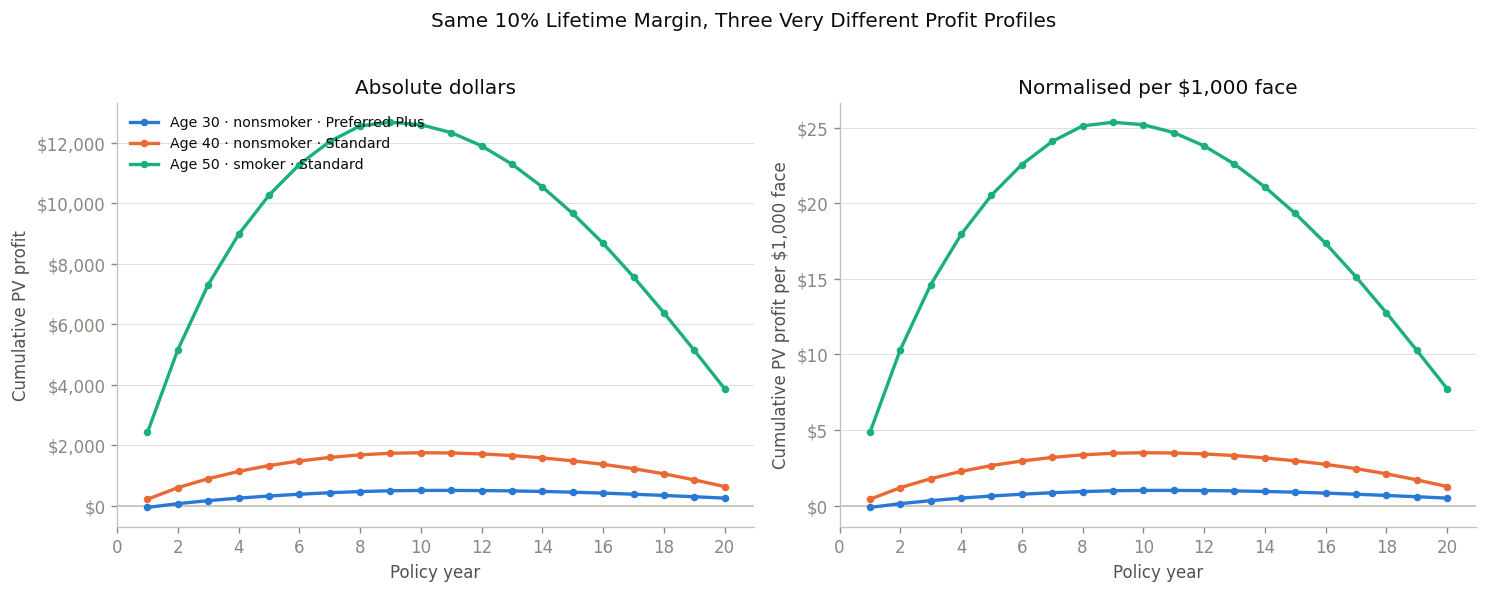

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))

for label, profile, color in COMPARISON:
    frame = comparison_frames[label]
    ax1.plot(frame["Year"], frame["Cum. PV Profit"], color=color, marker="o", markersize=3.5, linewidth=2, label=label, zorder=3)
    per_1000 = frame["Cum. PV Profit"] / (profile["face_amount"] / 1000)
    ax2.plot(frame["Year"], per_1000, color=color, marker="o", markersize=3.5, linewidth=2, label=label, zorder=3)

for ax, ylabel, title in (
    (ax1, "Cumulative PV profit", "Absolute dollars"),
    (ax2, "Cumulative PV profit per $1,000 face", "Normalised per $1,000 face"),
):
    ax.axhline(0, color=BASELINE, linewidth=1.0, zorder=1)
    ax.set_xlabel("Policy year")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(range(0, ASSUMPTIONS.term_years + 1, 2))
    ax.yaxis.set_major_formatter(DOLLARS)
    style(ax)

ax1.legend(loc="upper left", frameon=False, fontsize=8.5)
fig.suptitle("Same 10% Lifetime Margin, Three Very Different Profit Profiles", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

All three earn exactly 10% of PV premium over 20 years, yet their economics differ sharply. The
age-50 smoker generates an order of magnitude more absolute profit — but it does so by collecting
a far larger premium against a far larger mortality cost, and its cumulative profit peaks
*earlier* and gives back a larger share. The age-30 Preferred Plus policy is a small, slow,
stable contract whose profit accumulates gently and is barely eroded by the tail.

For an insurer this matters for reasons the single margin number cannot express: capital is tied
up for different lengths of time, the older/riskier business is far more exposed to a mortality
deterioration in its final third, and the same "10% product" behaves completely differently
depending on who buys it.

<a id="Part-4"></a>
## Part 4 — Lapse risk and stranded acquisition cost

The classic concern: the insurer has already paid acquisition costs, commissions and underwriting
expense, and if the policyholder lapses early those costs are stranded while the future premiums
that were meant to recoup them never arrive.

$$ LapseDrag = PVProfit_{\text{base}} - PVProfit_{\text{high lapse}} $$

Positive drag = the lapse stress **destroyed** profit. Premium is held fixed at the base indicated
premium throughout (see the note at the top).

### First: the headline stress, $l_1: 6\% \rightarrow 12\%$

In [11]:
def with_lapse_multipliers(multiplier_by_duration):
    """Scenario that scales specified durations' lapse rates; others unchanged."""

    def mutate(raw):
        raw["lapse"]["by_duration"] = {
            duration: min(max(rate * multiplier_by_duration.get(duration, 1.0), 0.0), 1.0)
            for duration, rate in raw["lapse"]["by_duration"].items()
        }

    return mutate


def stressed_pv_profit(scenario_mutate, mortality_rates_qx=None):
    """PV profit under a stress, premium HELD FIXED at base_premium (see note above)."""

    scenario_assumptions = apply_scenario(ASSUMPTIONS, scenario_mutate)
    _, _, summary = price_policy(
        scenario_assumptions, **POLICY,
        mortality_rates_qx=mortality_rates_qx, annual_premium=base_premium,
    )
    return summary.pv_profit


base_l1 = ASSUMPTIONS.lapse_rates[1]
high_lapse_pv = stressed_pv_profit(with_lapse_multipliers({1: 2.0}))
lapse_drag = base_summary.pv_profit - high_lapse_pv

print(f"Base   l_1 = {base_l1:.1%}   ->  PV profit = ${base_summary.pv_profit:,.2f}")
print(f"Stress l_1 = {base_l1 * 2:.1%}   ->  PV profit = ${high_lapse_pv:,.2f}")
print()
print(f"Lapse drag = ${lapse_drag:,.2f}  ({lapse_drag / base_summary.pv_profit:.2%} of base PV profit)")

Base   l_1 = 6.0%   ->  PV profit = $629.92
Stress l_1 = 12.0%   ->  PV profit = $603.09

Lapse drag = $26.83  (4.26% of base PV profit)


Doubling the *first-year* lapse rate does destroy profit, exactly as the stranded-cost intuition
predicts. But that intuition is about duration 1. Does it hold at every duration?

### Duration-specific lapse shock: $l_k' = 2 l_k$ for one $k$ at a time

In [12]:
durations = list(range(1, ASSUMPTIONS.term_years + 1))
lapse_shock = []
for k in durations:
    shocked_pv = stressed_pv_profit(with_lapse_multipliers({k: 2.0}))
    lapse_shock.append(shocked_pv - base_summary.pv_profit)

lapse_shock_frame = pd.DataFrame({"Duration k": durations, "ΔPV Profit": lapse_shock})
lapse_shock_frame["Lapse drag"] = -lapse_shock_frame["ΔPV Profit"]
lapse_shock_frame.set_index("Duration k").map(lambda x: f"${x:,.2f}")

,ΔPV Profit,Lapse drag
Duration k,,
1,$-26.83,$26.83
2,$-2.06,$2.06
3,$12.87,$-12.87
4,$22.54,$-22.54
5,$28.97,$-28.97
6,$32.51,$-32.51
7,$33.91,$-33.91
8,$34.68,$-34.68
9,$35.24,$-35.24


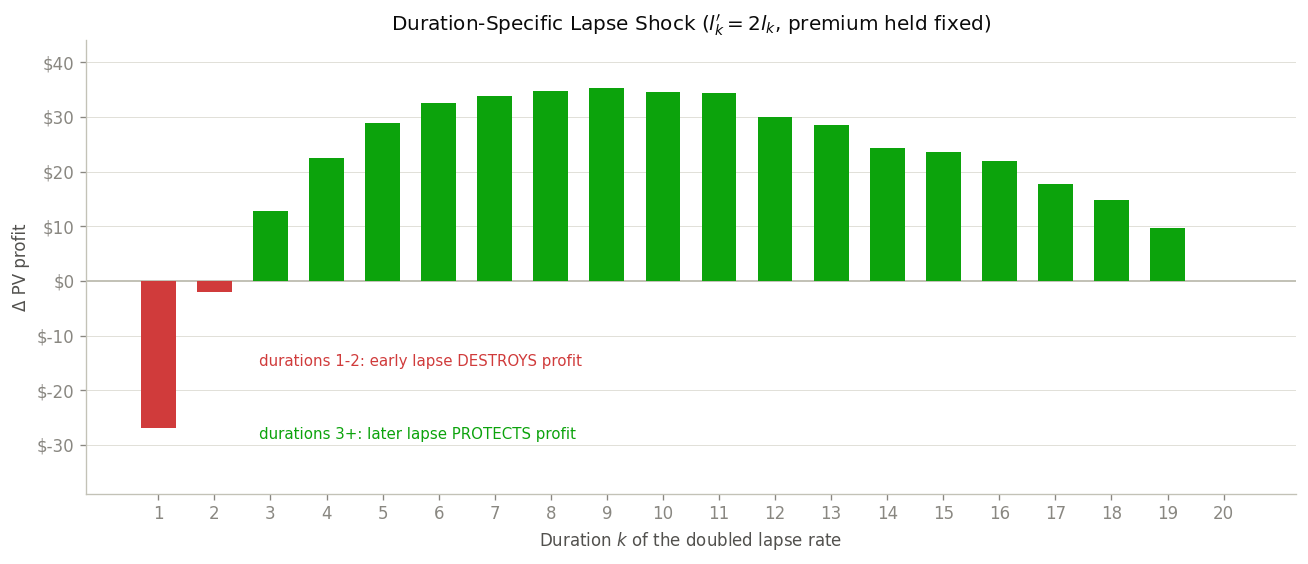

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.8))

colors = [CRITICAL if v < 0 else GOOD for v in lapse_shock_frame["ΔPV Profit"]]
ax.bar(lapse_shock_frame["Duration k"], lapse_shock_frame["ΔPV Profit"], color=colors, width=0.62, zorder=2)
ax.axhline(0, color=BASELINE, linewidth=1.2, zorder=1)

ax.set_xlabel("Duration $k$ of the doubled lapse rate")
ax.set_ylabel("Δ PV profit")
ax.set_title("Duration-Specific Lapse Shock ($l_k' = 2l_k$, premium held fixed)")
ax.set_xticks(durations)
ax.yaxis.set_major_formatter(DOLLARS)
style(ax)

low, high = lapse_shock_frame["ΔPV Profit"].min(), lapse_shock_frame["ΔPV Profit"].max()
ax.set_ylim(low * 1.45, high * 1.25)
ax.text(2.8, low * 0.55, "durations 1-2: early lapse DESTROYS profit",
        fontsize=9, color=CRITICAL, va="center")
ax.text(2.8, low * 1.05, "durations 3+: later lapse PROTECTS profit",
        fontsize=9, color=GOOD, va="center")

plt.tight_layout()
plt.show()

In [14]:
harmful = lapse_shock_frame[lapse_shock_frame["ΔPV Profit"] < 0]
helpful = lapse_shock_frame[lapse_shock_frame["ΔPV Profit"] > 0]
print(f"Durations where extra lapse DESTROYS profit: {list(harmful['Duration k'])}")
print(f"Durations where extra lapse INCREASES profit: {list(helpful['Duration k'])}")
print()
print(f"Worst duration: k={int(lapse_shock_frame.loc[lapse_shock_frame['ΔPV Profit'].idxmin(), 'Duration k'])} "
      f"(ΔPV = ${lapse_shock_frame['ΔPV Profit'].min():,.2f})")
print(f"Best duration:  k={int(lapse_shock_frame.loc[lapse_shock_frame['ΔPV Profit'].idxmax(), 'Duration k'])} "
      f"(ΔPV = ${lapse_shock_frame['ΔPV Profit'].max():,.2f})")

Durations where extra lapse DESTROYS profit: [1, 2]
Durations where extra lapse INCREASES profit: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

Worst duration: k=1 (ΔPV = $-26.83)
Best duration:  k=9 (ΔPV = $35.24)


### The result: this product is *lapse-supported*

The stranded-acquisition-cost story is real, but it holds for **duration 1 only** (and marginally
duration 2). From duration 3 onwards, extra lapses **increase** PV profit — peaking at duration 9,
where the benefit ($35) is larger than the year-1 damage ($27), and staying positive across
seventeen of the twenty durations.

This follows directly from Part 1's profit signature. A policyholder who lapses in year 6 walks
away *before* entering the loss-making years 11–20. The insurer keeps the surplus already
collected and is released from a future obligation that was, in expectation, worth less than
nothing. In industry terms this product's pricing is **lapse-supported**: it relies on a portion
of policyholders leaving before the tail.

That has a sharp practical consequence, and it is the opposite of the naive reading. The
dangerous lapse scenario for this product is not high lapse — it is **low** lapse in later
durations, where every policy that persists into years 11–20 drags profit down. The year-20 shock
lapse in the assumption table (31%, the end-of-level-period spike) is doing real economic work
here. Note also that $k=20$ shows exactly zero effect: lapsing in the final policy year removes no
future cash flow, because there is no future left.

Two honest caveats. First, this conclusion is a property of a model with **no reserves and no
cash surrender values** — a reserved product returns value to lapsing policyholders, which damps
(and can reverse) the lapse benefit. Second, real lapse behaviour is not independent of mortality:
healthy lives lapse preferentially and sick lives persist (anti-selection), so a real high-lapse
scenario also worsens the mortality of who remains. This engine models lapse and mortality as
independent competing decrements (`PROJECT_SPEC.md` section 7), so that second-order effect is
absent by construction — see `MODEL_LIMITATIONS.md`.

<a id="Part-5"></a>
## Part 5 — Mortality shock by duration

The natural question: **is an unexpected death in year 2 economically worse than one in year 18?**
The intuition is compelling — the benefit is paid earlier (less discounting) and fewer premiums
have been collected against it.

It turns out this question has *two* answers, depending on what "a mortality shock" means, and
they point in opposite directions. Both are computed below.

### Answer 1 — the rate shock: $q_k' = 2q_k$ for one duration at a time

In [15]:
base_qx = list(mortality_curve_for_policy(ASSUMPTIONS, **POLICY))

mortality_shock = []
for k in durations:
    shocked_qx = list(base_qx)
    shocked_qx[k - 1] = min(shocked_qx[k - 1] * 2.0, 1.0)
    _, _, shocked_summary = price_policy(
        ASSUMPTIONS, **POLICY, mortality_rates_qx=shocked_qx, annual_premium=base_premium
    )
    mortality_shock.append(shocked_summary.pv_profit - base_summary.pv_profit)

mortality_frame = pd.DataFrame({"Duration k": durations, "ΔPV Profit": mortality_shock})
mortality_frame.set_index("Duration k").map(lambda x: f"${x:,.2f}")

,ΔPV Profit
Duration k,
1,$-80.90
2,$-127.49
3,$-164.04
4,$-176.10
5,$-185.17
6,$-194.56
7,$-198.85
8,$-204.00
9,$-213.98


Every duration is negative (a mortality shock always costs money), but the damage **grows** with
duration — a doubling at $k=20$ costs far more than at $k=1$. That directly contradicts the
intuition above.

The reason is that a *rate* shock is not an *event*. Doubling $q_k$ adds $q_k$ worth of extra
death probability, and $q_{20} \approx 0.00369$ is roughly **22 times** $q_1 \approx 0.00017$. The
sheer size of the base rate at later durations swamps both the extra discounting and the smaller
surviving in-force. So "mortality is 2× worse than expected in year 20" really is a bigger event
than the same statement about year 1.

### Answer 2 — per-event severity: what does *one* unexpected death cost?

This is the question the intuition was actually asking. We normalise each shock by the extra
expected deaths it produced, giving the PV cost **per additional death**:

$$ Severity_k = \frac{\Delta PVProfit_k}{\Delta \mathbb{E}[\text{deaths}]_k} $$

In [16]:
base_expected_deaths = sum(r.death_probability for r in base_cash_flows)

severity = []
for k in durations:
    shocked_qx = list(base_qx)
    shocked_qx[k - 1] = min(shocked_qx[k - 1] * 2.0, 1.0)
    _, shocked_cash_flows, shocked_summary = price_policy(
        ASSUMPTIONS, **POLICY, mortality_rates_qx=shocked_qx, annual_premium=base_premium
    )
    extra_deaths = sum(r.death_probability for r in shocked_cash_flows) - base_expected_deaths
    severity.append((shocked_summary.pv_profit - base_summary.pv_profit) / extra_deaths)

mortality_frame["PV cost per extra death"] = severity
mortality_frame.set_index("Duration k").map(lambda x: f"${x:,.0f}")

,ΔPV Profit,PV cost per extra death
Duration k,,
1,$-81,"$-484,111"
2,$-127,"$-460,358"
3,$-164,"$-437,706"
4,$-176,"$-416,081"
5,$-185,"$-395,471"
6,$-195,"$-375,836"
7,$-199,"$-357,133"
8,$-204,"$-339,321"
9,$-214,"$-322,365"


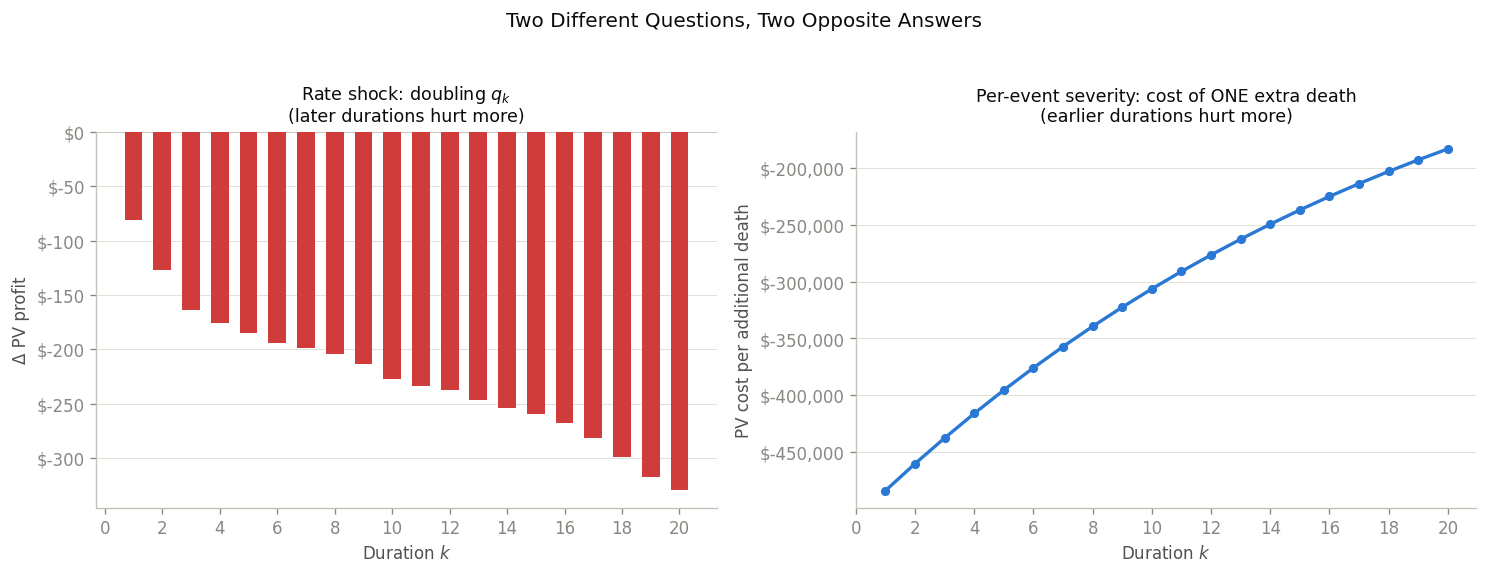

Cost of one extra death at duration 1:  $-484,111
Cost of one extra death at duration 20: $-182,793
Ratio: an early death is 2.65x as expensive as a late one.


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax1.bar(mortality_frame["Duration k"], mortality_frame["ΔPV Profit"], color=CRITICAL, width=0.62, zorder=2)
ax1.axhline(0, color=BASELINE, linewidth=1.0, zorder=1)
ax1.set_title("Rate shock: doubling $q_k$\n(later durations hurt more)", fontsize=10.5)
ax1.set_ylabel("Δ PV profit")

ax2.plot(mortality_frame["Duration k"], mortality_frame["PV cost per extra death"],
         color=BLUE, marker="o", markersize=4.5, linewidth=2, zorder=3)
ax2.set_title("Per-event severity: cost of ONE extra death\n(earlier durations hurt more)", fontsize=10.5)
ax2.set_ylabel("PV cost per additional death")

for ax in (ax1, ax2):
    ax.set_xlabel("Duration $k$")
    ax.set_xticks(range(0, ASSUMPTIONS.term_years + 1, 2))
    ax.yaxis.set_major_formatter(DOLLARS)
    style(ax)

fig.suptitle("Two Different Questions, Two Opposite Answers", fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

first, last = severity[0], severity[-1]
print(f"Cost of one extra death at duration 1:  ${first:,.0f}")
print(f"Cost of one extra death at duration 20: ${last:,.0f}")
print(f"Ratio: an early death is {first / last:.2f}x as expensive as a late one.")

On a **per-event** basis the original intuition is exactly right: an unexpected death at duration
1 costs roughly 2.6× what one at duration 20 costs. The insurer pays a near-undiscounted $500,000
having collected a single premium, and forfeits twenty years of future margin. A death at duration
20 is discounted twenty years, nineteen premiums have already been banked, and the forfeited
future is a single loss-making year — which the insurer was arguably better off without.

So both statements are true and they are not in conflict:

- **Per policyholder-event**, early deaths are far more expensive.
- **Per unit of rate deterioration**, later durations dominate, because that is where the base
  mortality rates — and therefore the absolute number of extra claims — actually are.

Knowing which one an interviewer is asking about is the whole skill.

### The economic danger map

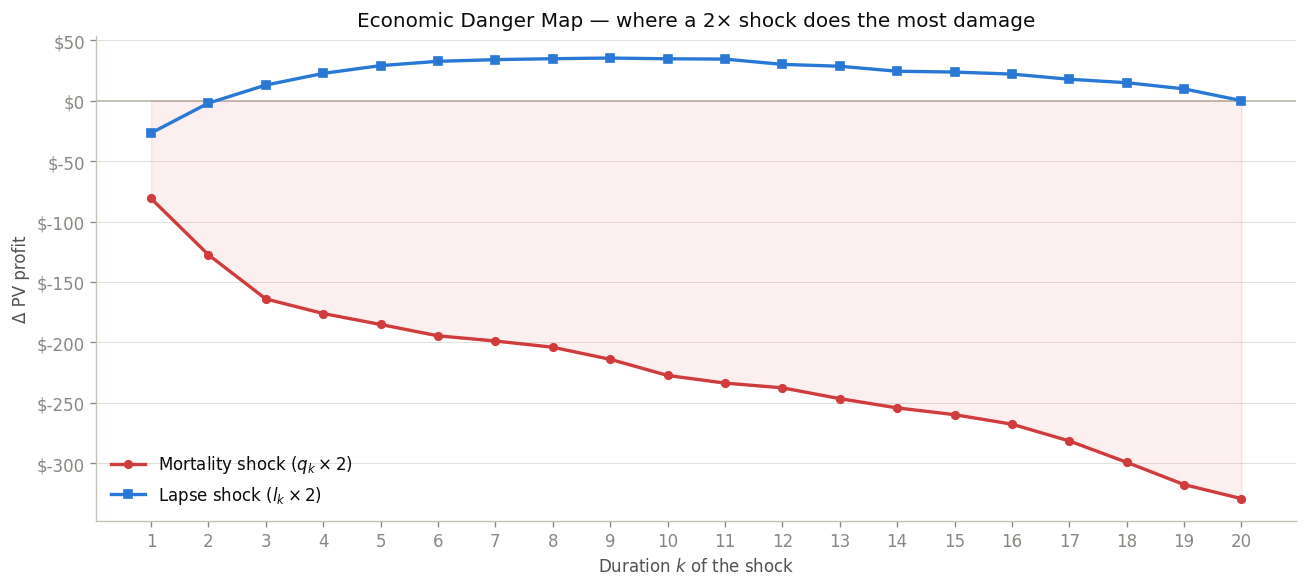

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(mortality_frame["Duration k"], mortality_frame["ΔPV Profit"],
        color=CRITICAL, marker="o", markersize=4.5, linewidth=2, label="Mortality shock ($q_k \\times 2$)", zorder=3)
ax.plot(lapse_shock_frame["Duration k"], lapse_shock_frame["ΔPV Profit"],
        color=BLUE, marker="s", markersize=4.5, linewidth=2, label="Lapse shock ($l_k \\times 2$)", zorder=3)
ax.axhline(0, color=BASELINE, linewidth=1.2, zorder=1)
ax.fill_between(durations, mortality_frame["ΔPV Profit"], 0, color=CRITICAL, alpha=0.08, zorder=2)

ax.set_xlabel("Duration $k$ of the shock")
ax.set_ylabel("Δ PV profit")
ax.set_title("Economic Danger Map — where a 2× shock does the most damage")
ax.set_xticks(durations)
ax.yaxis.set_major_formatter(DOLLARS)
style(ax)
ax.legend(loc="lower left", frameon=False)

plt.tight_layout()
plt.show()

The map summarises this policy's whole risk profile in one picture. Mortality risk is unambiguous
and rises steadily with duration — the insurer's exposure to an adverse mortality trend is
concentrated in the back half of the term, precisely where the profit signature is already
negative. Lapse risk crosses zero at duration 3 and is *protective* thereafter. The two lines move
in opposite directions, which is why the late durations are the ones to watch: they combine the
largest mortality exposure with the greatest dependence on policyholders continuing to leave.

<a id="Part-6"></a>
## Part 6 — Profit distribution across the portfolio

Everything so far has been one policy. `life_pricing.portfolio_pricing` prices all 10,000
policies in the synthetic book, giving `pv_profit` per policy at the **book premium** — the
rate-cell-banded premium actually charged, not each policy's individually-indicated premium (see
`ACTUARIAL_ASSUMPTIONS.md`, "Portfolio pricing (V1.1)"). That distinction is what makes the spread
below meaningful: at indicated premium every policy would sit exactly at a 10% margin by
construction.

$$ ProfitDensity_i = \frac{PVProfit_i}{FaceAmount_i / 1000} $$

In [19]:
portfolio = generate_synthetic_portfolio(ASSUMPTIONS)
priced = evaluate_portfolio_pricing(ASSUMPTIONS, portfolio)
priced["profit_density"] = priced["pv_profit"] / (priced["face_amount"] / 1000)

print(f"Priced {len(priced):,} policies.")

stats = pd.DataFrame({
    "Metric": [
        "Median PV profit", "5th percentile", "95th percentile", "Mean PV profit",
        "Median profit density (per $1,000 face)",
        "5th percentile density", "95th percentile density",
        "Portfolio PV profit margin",
    ],
    "Value": [
        f"${priced['pv_profit'].median():,.2f}",
        f"${priced['pv_profit'].quantile(0.05):,.2f}",
        f"${priced['pv_profit'].quantile(0.95):,.2f}",
        f"${priced['pv_profit'].mean():,.2f}",
        f"${priced['profit_density'].median():,.2f}",
        f"${priced['profit_density'].quantile(0.05):,.2f}",
        f"${priced['profit_density'].quantile(0.95):,.2f}",
        f"{priced['pv_profit'].sum() / priced['pv_premiums'].sum():.2%}",
    ],
})
stats.set_index("Metric")

Priced 10,000 policies.


,Value
Metric,
Median PV profit,$428.97
5th percentile,"$-3,471.73"
95th percentile,"$6,771.06"
Mean PV profit,$922.30
"Median profit density (per $1,000 face)",$0.97
5th percentile density,$-6.02
95th percentile density,$14.20
Portfolio PV profit margin,8.25%


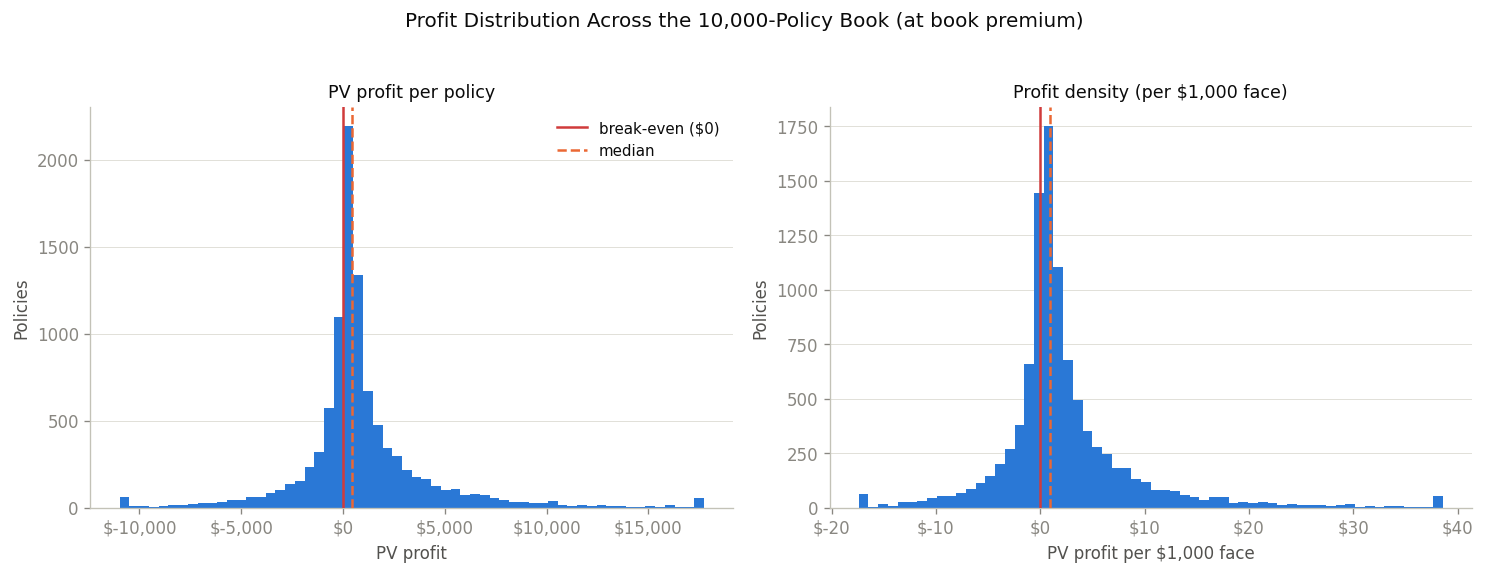

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

for ax, column, title, xlabel in (
    (ax1, "pv_profit", "PV profit per policy", "PV profit"),
    (ax2, "profit_density", "Profit density (per $1,000 face)", "PV profit per $1,000 face"),
):
    values = priced[column]
    low, high = values.quantile(0.005), values.quantile(0.995)
    ax.hist(values.clip(low, high), bins=60, color=BLUE, zorder=2)
    ax.axvline(0, color=CRITICAL, linewidth=1.5, zorder=3)
    ax.axvline(values.median(), color=ORANGE, linewidth=1.5, linestyle="--", zorder=3)
    ax.set_title(title, fontsize=10.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Policies")
    ax.xaxis.set_major_formatter(DOLLARS)
    style(ax)

handles = [
    plt.Line2D([], [], color=CRITICAL, linewidth=1.5, label="break-even ($0)"),
    plt.Line2D([], [], color=ORANGE, linewidth=1.5, linestyle="--", label="median"),
]
ax1.legend(handles=handles, loc="upper right", frameon=False, fontsize=9)
fig.suptitle("Profit Distribution Across the 10,000-Policy Book (at book premium)", fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

The spread is enormous relative to the average. The portfolio earns a healthy aggregate margin,
but the median policy earns far less than the mean — the distribution is strongly right-skewed,
with a small number of large, older, riskier policies contributing a disproportionate share of
total profit while a substantial left tail loses money outright.

**Profit density** is what makes these comparable. A $1,000,000 policy earning \$2,000 and a
\$150,000 policy earning \$400 look incomparable in absolute dollars, but at \$2.00 and \$2.67 per
\$1,000 of face the smaller policy is the better piece of business per unit of risk carried.

<a id="Part-7"></a>
## Part 7 — "Bad business" identification

$$ PVProfit_i < 0 $$

Because policies are charged a **book** premium set at rate-cell granularity, individual policies
inside a cell are cross-subsidised: those whose indicated premium exceeds the cell's book premium
lose money, funded by those whose indicated premium is below it. This is not a modelling error —
it is what every real filed rate table does, and quantifying it is the point.

In [21]:
loss_making = priced[priced["pv_profit"] < 0]

policy_pct = len(loss_making) / len(priced)
face_pct = loss_making["face_amount"].sum() / priced["face_amount"].sum()
loss_total = loss_making["pv_profit"].sum()
profit_total = priced.loc[priced["pv_profit"] >= 0, "pv_profit"].sum()

print(f"Loss-making policies:          {len(loss_making):,} of {len(priced):,}   ({policy_pct:.2%})")
print(f"Loss-making face amount:       ${loss_making['face_amount'].sum():,.0f} of ${priced['face_amount'].sum():,.0f}   ({face_pct:.2%})")
print()
print(f"Total loss from loss-makers:   ${loss_total:,.0f}")
print(f"Total profit from profitable:  ${profit_total:,.0f}")
print(f"Net portfolio PV profit:       ${priced['pv_profit'].sum():,.0f}")
print(f"Gross-to-net erosion:          {-loss_total / profit_total:.1%} of gross profit is consumed by loss-making business")

Loss-making policies:          3,036 of 10,000   (30.36%)
Loss-making face amount:       $1,800,730,000 of $5,450,310,000   (33.04%)

Total loss from loss-makers:   $-5,683,685
Total profit from profitable:  $14,906,696
Net portfolio PV profit:       $9,223,011
Gross-to-net erosion:          38.1% of gross profit is consumed by loss-making business


In [22]:
def loss_rate_by(column):
    grouped = priced.groupby(column, observed=True).apply(
        lambda g: pd.Series({
            "Policies": len(g),
            "Loss-making %": (g["pv_profit"] < 0).mean(),
            "Face at risk %": g.loc[g["pv_profit"] < 0, "face_amount"].sum() / g["face_amount"].sum(),
            "Mean PV profit": g["pv_profit"].mean(),
        }),
        include_groups=False,
    )
    return grouped


for dimension in ["issue_age_band", "smoker_status", "underwriting_class", "face_amount_band"]:
    table = loss_rate_by(dimension)
    formatted = table.copy()
    formatted["Policies"] = formatted["Policies"].map(lambda x: f"{int(x):,}")
    formatted["Loss-making %"] = formatted["Loss-making %"].map(lambda x: f"{x:.1%}")
    formatted["Face at risk %"] = formatted["Face at risk %"].map(lambda x: f"{x:.1%}")
    formatted["Mean PV profit"] = formatted["Mean PV profit"].map(lambda x: f"${x:,.0f}")
    print(f"\n=== By {dimension} ===")
    print(formatted.to_string())


=== By issue_age_band ===
               Policies Loss-making % Face at risk % Mean PV profit
issue_age_band                                                     
25-34             2,829         24.5%          27.3%           $271
35-44             2,790         32.2%          35.4%           $432
45-54             2,748         33.7%          35.9%         $1,099
55-60             1,633         31.8%          34.0%         $2,590

=== By smoker_status ===
              Policies Loss-making % Face at risk % Mean PV profit
smoker_status                                                     
nonsmoker        8,534         29.8%          32.5%           $759
smoker           1,466         33.7%          36.3%         $1,873

=== By underwriting_class ===
                   Policies Loss-making % Face at risk % Mean PV profit
underwriting_class                                                     
Preferred             3,976         29.6%          31.9%           $812
Preferred Plus        1,

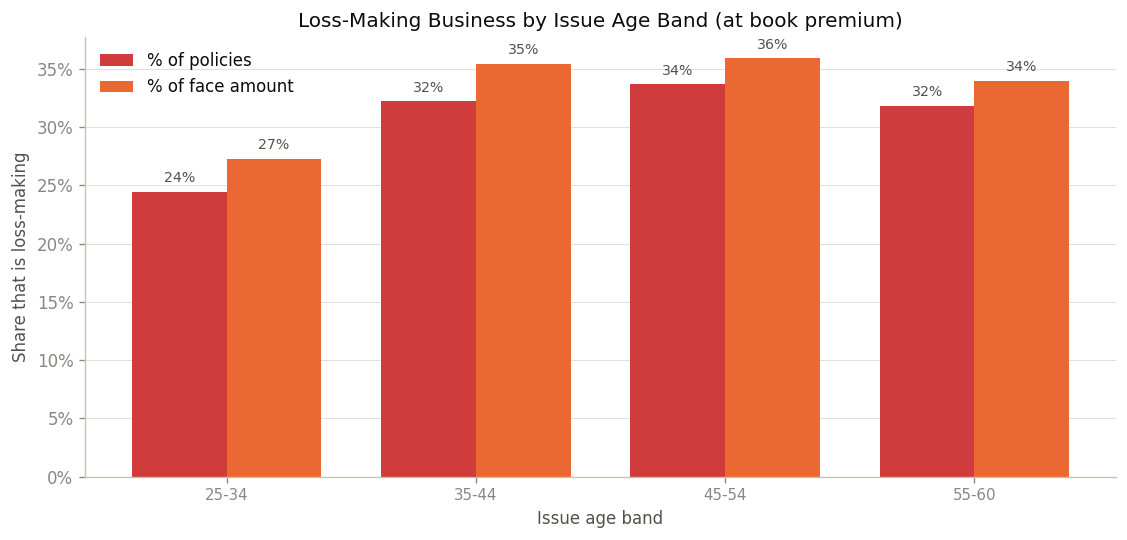

In [23]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))

table = loss_rate_by("issue_age_band").sort_index()
positions = np.arange(len(table))
width = 0.38

ax.bar(positions - width / 2, table["Loss-making %"], width=width, color=CRITICAL, label="% of policies", zorder=2)
ax.bar(positions + width / 2, table["Face at risk %"], width=width, color=ORANGE, label="% of face amount", zorder=2)

ax.set_xticks(positions)
ax.set_xticklabels(table.index, fontsize=9)
ax.set_xlabel("Issue age band")
ax.set_ylabel("Share that is loss-making")
ax.set_title("Loss-Making Business by Issue Age Band (at book premium)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
style(ax)
ax.legend(frameon=False)

for position, (policy_share, face_share) in enumerate(zip(table["Loss-making %"], table["Face at risk %"])):
    ax.text(position - width / 2, policy_share + 0.008, f"{policy_share:.0%}", ha="center", fontsize=8.5, color=SECONDARY_INK)
    ax.text(position + width / 2, face_share + 0.008, f"{face_share:.0%}", ha="center", fontsize=8.5, color=SECONDARY_INK)

plt.tight_layout()
plt.show()

### What this investigation found

A book carrying a healthy aggregate margin contains a large minority of individually
loss-making policies, and they consume a meaningful share of the gross profit the profitable
business generates. The concentration is not uniform — the segment tables above identify exactly
where the cross-subsidy sits.

Three caveats keep this honest. First, "loss-making" here means *relative to the banded book
premium*: every one of these policies is profitable at its own indicated premium, so this measures
**rate-table granularity**, not mispriced risk. Second, everything is on an expected-value basis —
a real book also carries volatility risk around these expectations, which this deterministic
engine does not model. Third, all of it inherits the tail exposure Parts 1–5 identified: the
portfolio's profit is front-loaded and depends on lapses continuing to remove policies before the
loss-making final third of the term.

The natural follow-up — narrowing the rate cells to shrink the cross-subsidy, and testing whether
that survives contact with lapse and mortality stress — is a portfolio-level version of exactly
the analysis this notebook ran on one policy.